In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd 

In [2]:
shapefile = gpd.read_file("/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Uni/Masterthesis/data/river_network/shapefile.feather", index=True)
shapefile.set_index(["__index_level_0__", "__index_level_1__", "__index_level_2__"], inplace=True)
shapefile.index.names = [None] * 3

In [3]:
shapefile

NORIOCOMP        CORIO  \
0      0 0                                          Água Azul    8641516_0   
1      0 0                                        Água Bonita  864142512_0   
2      0 0                                        Água Bonita    8962984_0   
3      0 0  Água Bonita ou das Pontinhas e Água do Capão B...   86432922_0   
         1  Água Bonita ou das Pontinhas e Água do Capão B...   86432922_0   
...                                                       ...          ...   
161531 0 0                                               None         None   
161532 0 0                                               None         None   
161533 0 0                                               None         None   
161534 0 0                                               None         None   
161535 0 0                                               None         None   

            downstream_node_id  upstream_node_id    adm2  estuary    river  \
0      0 0             75450.0          493402.0  3110.0    228.0   9478.0   
1      0 0             75974.0          494325.0  2954.0    228.0   9551.0   
2      0 0             67065.0          485868.0  1559.0    228.0  12434.0   
3      0 0            153605.0          498582.0  4759.0    228.0   9153.0   
         1            153606.0          153605.0  4759.0    228.0   9153.0   
...                        ...               ...     ...      ...      ...   
161531 0 0                 NaN          487842.0     NaN   1023.0      0.0   
161532 0 0             68579.0          486433.0     NaN   1024.0      0.0   
161533 0 0             68579.0          486793.0     NaN   1024.0      1.0   
161534 0 0             67656.0           67491.0     NaN     60.0     28.0   
161535 0 0                 NaN           68579.0     NaN   1024.0      0.0   

            segment  subsegment  \
0      0 0      0.0         0.0   
1      0 0      0.0         0.0   
2      0 0      0.0         0.0   
3      0 0      2.0         0.0   
         1      1.0         0.0   
...             ...         ...   
161531 0 0      0.0         0.0   
161532 0 0      1.0         0.0   
161533 0 0      0.0         0.0   
161534 0 0      0.0         0.0   
161535 0 0      0.0         0.0   

                                                     geometry  
0      0 0  LINESTRING (4010130.381 7424922.032, 4011257.1...  
1      0 0  LINESTRING (4037777.378 7384298.361, 4037034.2...  
2      0 0  LINESTRING (3804922.764 8019931.35, 3804511.20...  
3      0 0  LINESTRING (4176882.178 7440871.707, 4175687.8...  
         1  LINESTRING (4170252.538 7442847.873, 4170252.1...  
...                                                       ...  
161531 0 0  LINESTRING (3849965.585 10605057.641, 3850608....  
161532 0 0  LINESTRING (3818121.855 10606360.696, 3818074....  
161533 0 0  LINESTRING (3826386.147 10608748.764, 3826293....  
161534 0 0  LINESTRING (3797879.886 10615132.38, 3797842.7...  
161535 0 0  LINESTRING (3822757.94 10616623.77, 3822687.10...  

[542107 rows x 10 columns]

In [4]:
topology = gpd.read_file("/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Uni/Masterthesis/data/river_network/topology.feather")

In [6]:
topology.query("confluence").index

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       123130, 123131, 123132, 123133, 123134, 123135, 123136, 123137, 123138,
       123139],
      dtype='int64', length=123140)

In [11]:
shapefile[shapefile.downstream_node_id.isin(topology.query("confluence").index)].groupby("downstream_node_id").size().value_counts()

2    121669
1       984
Name: count, dtype: int64

In [20]:
topology

,estuary,confluence,source,border,geometry
0,False,True,False,False,POINT (943106.381 9375682.602)
1,False,True,False,False,POINT (943570.02 9421013.29)
2,False,True,False,False,POINT (943570.028 9424712.398)
3,False,True,False,False,POINT (944497.155 9436270.843)
4,False,True,False,False,POINT (944960.677 9420088.477)
...,...,...,...,...,...
543128,True,False,True,False,POINT (5912102.639 9198545.545)
543129,True,False,True,False,POINT (5912366.669 9202259.251)
543130,True,False,True,False,POINT (5912418.175 9182831.387)
543131,True,False,True,False,POINT (5912571.568 9193833.564)


In [3]:
drainage_polygons = gpd.read_file("/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Uni/Masterthesis/data/drainage/extracted_drainage_polygons.feather", rows=10)

In [4]:
drainage_polygons

,estuary,river,segment,subsegment,distance_from_estuary,__index_level_0__,__index_level_1__,geometry
0,136.0,41388.0,0.0,0.0,3.468000e+06,602,0,"MULTIPOLYGON (((-62.57772 -12.67584, -62.57712..."
1,136.0,41388.0,0.0,0.0,3.467000e+06,602,1,"POLYGON ((-62.50037 -12.68141, -62.49949 -12.6..."
2,136.0,41388.0,0.0,0.0,3.466000e+06,602,2,None
3,136.0,41388.0,0.0,0.0,3.465000e+06,602,3,None
4,136.0,41388.0,0.0,0.0,3.464000e+06,602,4,None
5,136.0,41388.0,0.0,0.0,3.463053e+06,602,5,None
6,136.0,41388.0,1.0,0.0,3.475000e+06,602,6,POLYGON EMPTY
7,136.0,41388.0,1.0,0.0,3.474000e+06,602,7,POLYGON EMPTY
8,136.0,41388.0,1.0,0.0,3.473000e+06,602,8,POLYGON EMPTY
9,136.0,41388.0,1.0,0.0,3.472000e+06,602,9,POLYGON EMPTY


In [23]:
from collections import defaultdict

def calculate_distance_from_estuary(rivers, topology, segment_length = 1000):
    """
    Calculates the distance of river segments from the nearest estuary. This function updates
    the `rivers` DataFrame by adding two new columns: `distance_from_estuary` and `segment_offset`.
    The calculation is done by tracing the river network upstream, starting from estuary points,
    to compute cumulative distances for each segment.

    Parameters:
    - rivers (pd.DataFrame): A DataFrame containing river network data. It must include columns
      for `downstream_node_id`, `upstream_node_id`, `length`, and identifying attributes for
      estuaries (e.g., 'river', 'segment', 'subsegment').
    - topology (pd.DataFrame): A DataFrame describing the topology of the network. It should
      contain Boolean columns `source` and `estuary` to identify river sources and estuaries.
    - segment_length (int, optional): The base segment length used to calculate segment offsets.
      Default value is 1000.

    Returns:
    - pd.DataFrame: The updated `rivers` DataFrame with added `distance_from_estuary` and
      `segment_offset` columns, representing the distance from the nearest estuary and the
      distance modulo the `segment_length`, respectively.

    Notes:
    - This function uses multiprocessing for calculating the distance from the estuary for each
      segment efficiently.
    - The function assumes all data are clean and correctly formatted. Missing values in the
      necessary columns may lead to failures or incorrect results.
    """
    # create a dict from end point to upstream river ids
    dict_points = defaultdict(list)
    # Iterate over pairs of corresponding tuples from both arrays
    for point, index in zip(rivers.dropna(subset = "downstream_node_id").downstream_node_id.astype(np.int32), rivers.dropna(subset = "downstream_node_id").index):
        # Append the index to the list corresponding to the point
        dict_points[point].append(index)
    # Convert defaultdict to dict
    downstream_lookup = dict(dict_points)
    # create a dict from river id to end node
    upstream_lookup = {key: value for key, value in zip(rivers.dropna(subset = "upstream_node_id").index, rivers.dropna(subset = "upstream_node_id").upstream_node_id.astype(np.int32))}
    # create a dict from river id to length
    length_lookup = {key: value for key, value in zip(rivers.dropna(subset = "upstream_node_id").index, rivers.dropna(subset = "upstream_node_id").length)}
    # create a dict to check if a point is a river source node
    end_node_lookup = {x: True for x in topology[topology.source & ~topology.estuary].index}

    # get all river ids of nodes at estuaries
    estuary_ids = rivers.query("river==0 & segment==0 & subsegment==0").index.to_list()

    # prepare data for multiprocessing
    datasets = []
    for i in range(len(estuary_ids)):
        datasets.append([{key: 0 for key in rivers[rivers.estuary == rivers.loc[estuary_ids[i]].estuary].dropna(subset = "upstream_node_id").index}, (estuary_ids[i], 0)])

    # function to calculate segment offsets
    def calculate_distance_from_estuary(dataset):
        query = [dataset[1]]
        out = dataset[0]
        while query:
            tmp = query.pop()
            out[tmp[0]] = tmp[1]
            if not end_node_lookup.get(upstream_lookup[tmp[0]], False):
                query += [(x, ((tmp[1] + length_lookup[tmp[0]]))) for x in downstream_lookup.get(upstream_lookup[tmp[0]], [])] # % 1000
        return out
    # compute segment offsets
    distance_from_estuary = [calculate_distance_from_estuary(x) for x in datasets]
    
    # write segment offsets to shapefile
    rivers["distance_from_estuary"] = np.nan
    rivers.update(pd.concat([pd.DataFrame({"distance_from_estuary": x}) for x in distance_from_estuary]))
    rivers["distance_from_estuary"] = pd.to_numeric(rivers.distance_from_estuary.round(0))
    rivers["segment_offset"] = pd.to_numeric(rivers.distance_from_estuary % segment_length)
    
    return rivers

In [24]:
test = calculate_distance_from_estuary(shapefile, topology)

In [ ]:
test.query("estuary==229").sort_values(["distance_from_estuary"])

In [34]:
test.query("estuary==229").sort_values(["river", "segment", "subsegment"])

NORIOCOMP     CORIO  downstream_node_id  \
39031 0 34  Rio da Ribeira do Iguape     794_0                 NaN   
        33  Rio da Ribeira do Iguape     794_0             89556.0   
        32  Rio da Ribeira do Iguape     794_0             89256.0   
        31  Rio da Ribeira do Iguape     794_0             89257.0   
        29  Rio da Ribeira do Iguape     794_0            302795.0   
...                              ...       ...                 ...   
8458  0 2     Córrego do Braço Preto  794142_0             89177.0   
        0     Córrego do Braço Preto  794142_0            301547.0   
38958 0 0              Rio da Momuna   79412_0             89556.0   
35493 0 0            Ribeirão Momuna   79412_1             89593.0   
41850 0 0              Rio Nhanguara  794122_0             89593.0   

            upstream_node_id    adm2  estuary  river  segment  subsegment  \
39031 0 34           89556.0  4946.0    229.0    0.0      0.0         0.0   
        33           89256.0  4946.0    229.0    0.0      1.0         0.0   
        32           89257.0  4946.0    229.0    0.0      2.0         0.0   
        31          302795.0  4946.0    229.0    0.0      3.0         0.0   
        29           89280.0  5121.0    229.0    0.0      4.0         0.0   
...                      ...     ...      ...    ...      ...         ...   
8458  0 2           301547.0  4946.0    229.0  209.0      0.0         0.0   
        0           507110.0  5121.0    229.0  209.0      1.0         0.0   
38958 0 0            89593.0  4946.0    229.0  210.0      0.0         0.0   
35493 0 0           507372.0  4946.0    229.0  210.0      1.0         0.0   
41850 0 0           507614.0  4946.0    229.0  211.0      0.0         0.0   

                                                     geometry  \
39031 0 34  LINESTRING (4479895.16 7183192.832, 4480002.08...   
        33  LINESTRING (4472844.179 7188209.957, 4472842.6...   
        32  LINESTRING (4472851.418 7188343.163, 4472844.1...   
        31  LINESTRING (4473031.988 7188719.979, 4473026.2...   
        29  LINESTRING (4473554.216 7189824.963, 4473550.5...   
...                                                       ...   
8458  0 2   LINESTRING (4470432.914 7184546.862, 4470561.9...   
        0   LINESTRING (4461303.115 7178138.865, 4461996.6...   
38958 0 0   LINESTRING (4480368.325 7180775.279, 4479731.7...   
35493 0 0   LINESTRING (4467201.75 7170302.976, 4467703.81...   
41850 0 0   LINESTRING (4472952.003 7179864.401, 4474039.2...   

            distance_from_estuary  segment_offset  
39031 0 34                    0.0             0.0  
        33                19497.0           497.0  
        32                35695.0           695.0  
        31                35829.0           829.0  
        29                36247.0           247.0  
...                           ...             ...  
8458  0 2                 40534.0           534.0  
        0                 40823.0           823.0  
38958 0 0                 19497.0           497.0  
35493 0 0                 22064.0            64.0  
41850 0 0                 22064.0            64.0  

[1430 rows x 12 columns]

<Axes: >

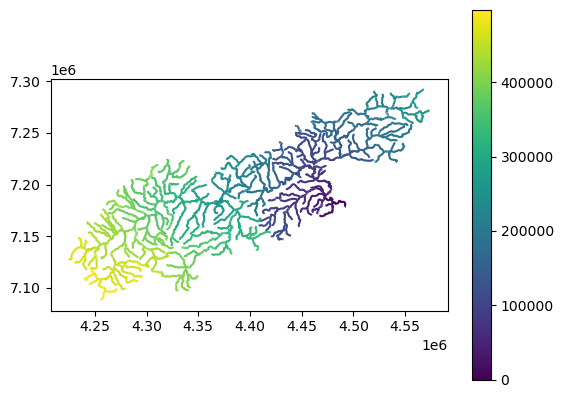

In [29]:
test.query("estuary==229").plot(column="distance_from_estuary", cmap="viridis", legend=True)

In [ ]:
# Merge distances back to edges for visualization/analysis
shapefile_with_dist = shapefile.merge(
    distances_df,
    left_on='upstream_node',
    right_on='node_id',
    how='left'
)
shapefile_with_dist.head()